In [55]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from rich import print
from sklearn.metrics import accuracy_score

In [56]:
customers = pd.read_csv('customers.csv')
Items = pd.read_csv('Items.csv')
order_item = pd.read_csv('order_item.csv')
orders = pd.read_csv('orders.csv')
display('customers', customers,'Items' , Items, 'order_item', order_item, 'orders', orders)
%config Completer.use_jedi = False



'customers'

,id,first_name,last_name,gender,age,nationallity,joining_date,phone_number,email
0,1,Eadie,Maffeo,Female,41.0,France,2022-01-11,534-341-9052,emaffeo0@smh.com.au
1,2,Hammad,Brewerton,Male,56.0,Isreal,2022-09-30,999-994-0510,hbrewerton1@discovery.com
2,3,Terrell,Bris,NaN,43.0,India,NaN,980-455-5208,tbris2@yale.edu
3,4,Frannie,Morewood,Male,84.0,France,2021-05-26,979-187-1493,fmorewood3@vistaprint.com
4,5,Sophi,Fleet,Female,33.0,Sweden,2021-07-19,991-853-9984,sfleet4@unicef.org
...,...,...,...,...,...,...,...,...,...
495,496,Renado,Monard,Male,53.0,India,NaN,399-472-4819,rmonarddr@yale.edu
496,497,Kalina,Luno,Female,30.0,Italy,2022-10-16,659-768-2522,klunods@friendfeed.com
497,498,Viv,Callander,Female,44.0,France,2021-02-24,447-685-9318,vcallanderdt@icq.com
498,499,Georg,Raper,Male,41.0,Germany,2022-04-24,863-207-4830,graperdu@homestead.com


'Items'

,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability
0,1,Television,Televisions and Displays,356.81,1009.0,NaN,True
1,2,Laptop,Computers and Accessories,1851.32,493.0,NaN,True
2,3,Desktop,Computers and Accessories,1121.84,334.0,HP,True
3,4,Smartphone,Mobile Devices and Accessories,965.20,201.0,NaN,True
4,5,Tablet,NaN,2739.61,190.0,Toshiba,True
5,6,Printer,Printers and Office Equipment,4175.99,971.0,Sony,True
6,7,Camera,Photography Equipment,2366.72,458.0,NaN,True
7,8,Headphone,NaN,3117.19,599.0,NaN,True
8,9,Speaker,Audio Equipment,4471.27,1360.0,Toshiba,True
9,10,DVD Player,Video Players and Recorders,453.85,605.0,NaN,True


'order_item'

,Unnamed: 0,id,order_id,item_id,quantity
0,0,1,337,10.0,2
1,1,2,430,27.0,6
2,2,3,430,36.0,2
3,3,4,508,46.0,1
4,4,5,229,27.0,2
...,...,...,...,...,...
995,995,996,594,24.0,2
996,996,997,330,32.0,8
997,997,998,472,10.0,3
998,998,999,222,29.0,1


'orders'

,order_id,customer_id,delivery_address,delivery_days,order_date,payment_method,order_source
0,1,477.0,576 Cordelia Place,2.0,2023-12-05,GIFT_CARD,WEBSITE
1,2,93.0,4664 6th Drive,4.0,2023-08-17,CASH,STORE
2,3,474.0,8766 4th Point,4.0,2023-02-25,CHECK,STORE
3,4,333.0,31 Bonner Way,3.0,2023-02-04,CASH,STORE
4,5,436.0,20352 Shelley Way,5.0,2023-06-01,CASH,STORE
...,...,...,...,...,...,...,...
595,596,110.0,26 Hudson Lane,5.0,2023-10-30,CREDIT_CARD,WEBSITE
596,597,209.0,37392 Sullivan Park,4.0,2023-08-23,CREDIT_CARD,WEBSITE
597,598,480.0,1473 Ilene Drive,4.0,2023-09-11,CASH,STORE
598,599,72.0,2 Nancy Crossing,4.0,2023-02-09,CASH,STORE


In [110]:
# Qestion 2
print(f'''[dark_orange]{'--'*25}[/dark_orange] [bold underline dark_orange] Qestion 2 [/bold underline dark_orange][dark_orange]{'--'*25}
{'--'*56}[/dark_orange]''')

# part 1- Data analysis:
print(f'[gold1]{'--'*22}[/gold1] [bold underline gold1] part 1- Data analysis [/bold underline gold1][gold1]{'--'*22}[/gold1]')


# task 1 - AVG price for an item:
print('[spring_green1]--[/spring_green1] [underline spring_green1]task 1 - AVG price for an item: [/underline spring_green1]')
Items.set_index('id')
average_price = Items['item_price'].mean()
print(f"The AVG price for an item is: {average_price:.3f}")

# task 2 - the person who purchase the most:
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 2 - the person who purchase the most: [/underline spring_green1]')
Purchased_the_most = (
    customers.merge(orders, left_on='id', right_on='customer_id', how='left', suffixes=('_co', '_o'))
             .merge(order_item, left_on='order_id', right_on='order_id', how='left', suffixes=('_Ptm', '_oi')))

# display(Purchased_the_most)
display(Purchased_the_most.groupby(['id_Ptm','first_name','last_name'])['quantity'].sum().nlargest(1).reset_index())

# task 3 - calc the total price per purchase:
maping_price = Items.set_index('id')['item_price']
order_item['total_price'] = order_item['item_id'].map(maping_price) * order_item['quantity']

# task 4 - every purchase and it's total price
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 3 + task 4 - calc the total price per purchase, then show every purchase and itws total price [/underline spring_green1]')
display(order_item.groupby('order_id')['total_price'].sum().reset_index())

# task 5 - the chipest/priciest/avg purchase:
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 5 - the chipest/priciest/avg purchase:[/underline spring_green1]')
tot_sales = order_item.groupby('order_id')['total_price'].sum()
max_order = tot_sales.nlargest(1).to_frame()
min_order = tot_sales.nsmallest(1).to_frame()
mean_order_price = tot_sales.mean()
# display(mean_order)
display('most expensive order' ,max_order, 'most low cost order', min_order, f'the average payment for an order: {mean_order_price:.2f}')

# task 6 - gender and nationality table:
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 6 - gender and nationality table:[/underline spring_green1]')
gender_by_nation = pd.pivot_table(customers, index='nationallity', columns='gender', values='id', aggfunc='count', fill_value=0)
display('gender by nationality:', gender_by_nation)

--------------------------------------------------  Qestion 2 --------------------------------------------------
----------------------------------------------------------------------------------------------------------------

--------------------------------------------  part 1- Data analysis --------------------------------------------

-- task 1 - AVG price for an item: 

The AVG price for an item is: 2222.083

-- task 2 - the person who purchase the most: 

...

,total_price
order_id,
289,0.0


'the average payment for an order: 14580.42'

-- task 6 - gender and nationality table:

'gender by nationality:'

gender,Agender,Bigender,Female,Genderfluid,Genderqueer,Male,Non-binary,Polygender
nationallity,,,,,,,,
Argentina,1,0,10,1,0,9,0,1
Brazil,0,0,6,0,0,17,2,1
Chile,1,0,14,0,0,9,0,0
China,0,0,4,1,1,9,0,1
France,1,0,15,1,0,10,0,0
Germany,0,0,14,0,1,5,1,1
India,1,0,8,0,0,14,0,0
Isreal,2,1,20,5,1,31,0,2
Italy,0,0,14,0,2,10,0,0


--------------------------------------------------  Qestion 2 --------------------------------------------------
----------------------------------------------------------------------------------------------------------------

--------------------------------------------  part 2 - graphs analasys --------------------------------------------

-- task 1 - Customer Distribution of Gender: 

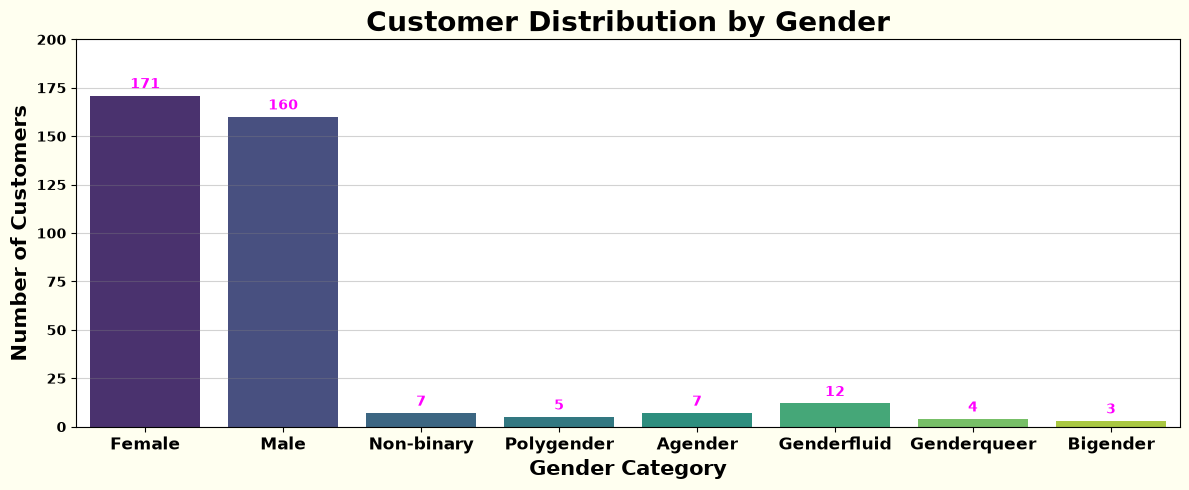

-- task 3 - Customer Distribution of nationallity: 

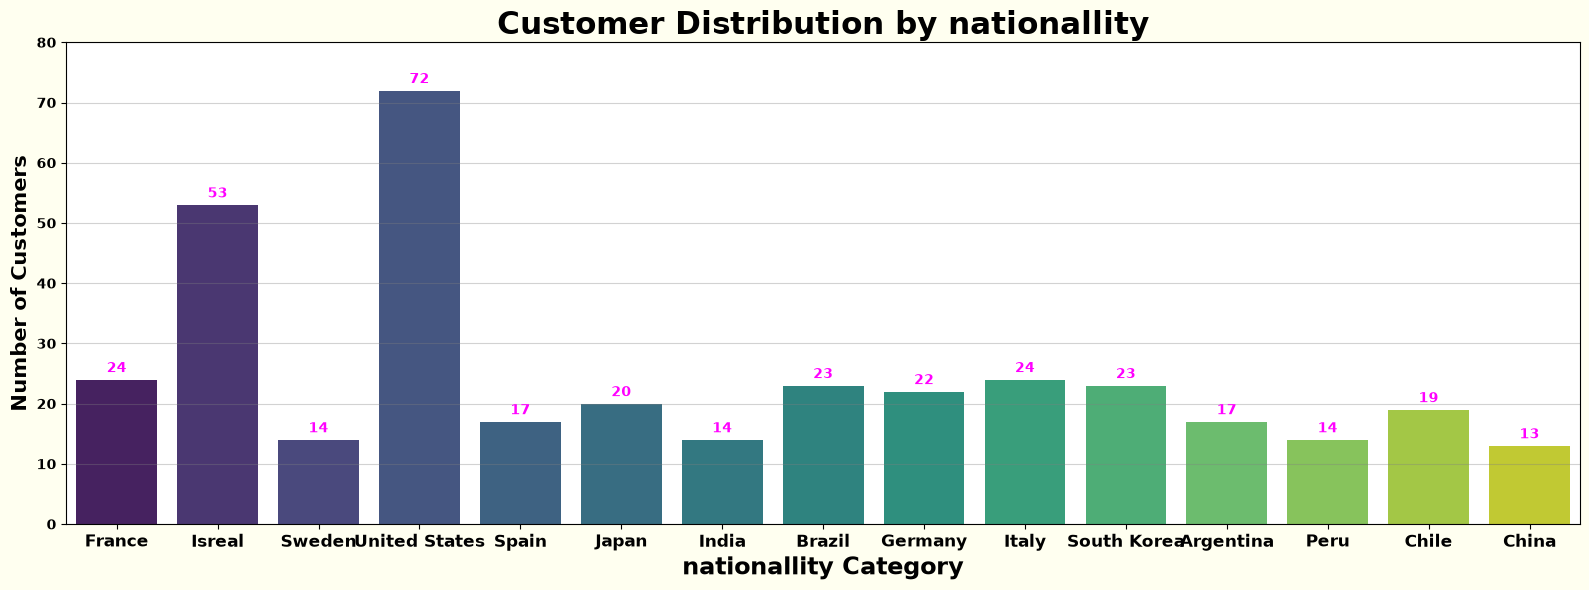

-- task 3 - Customer histography Distributionby of age: 

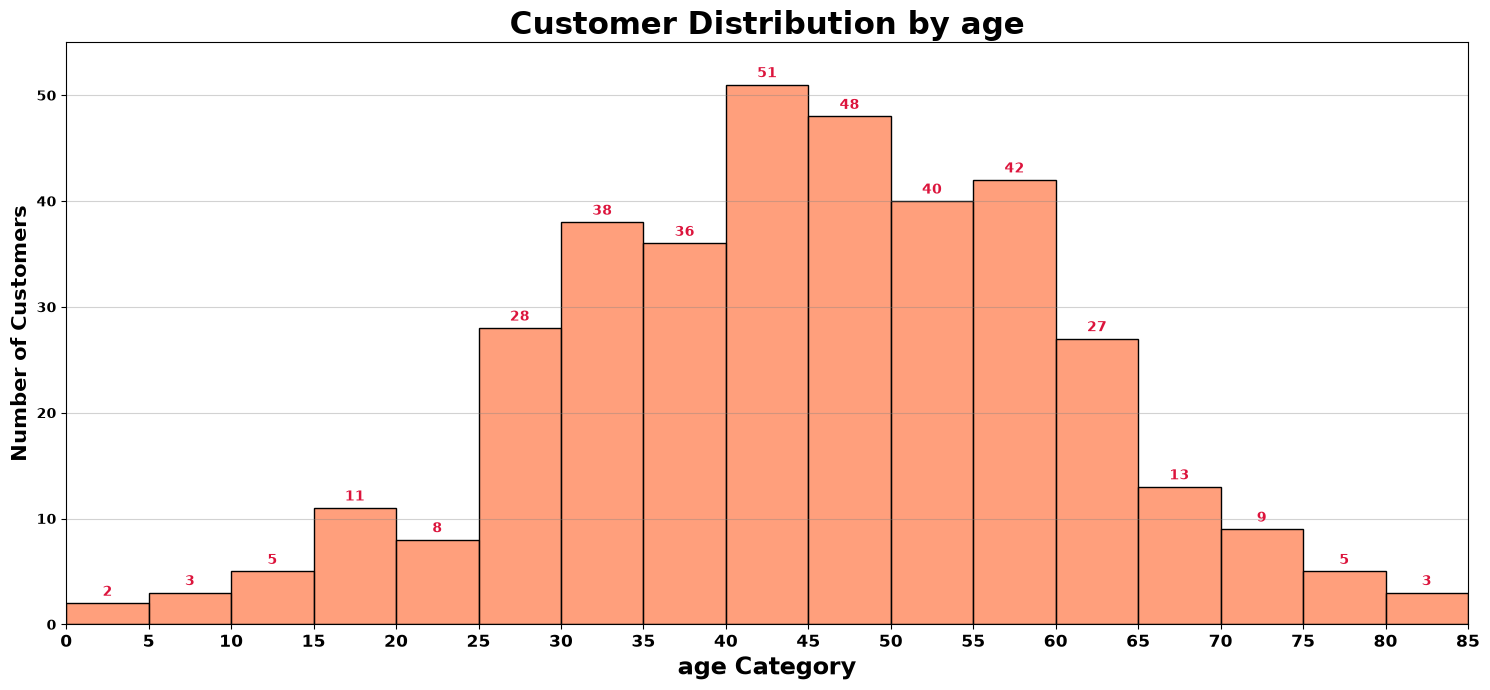

In [111]:
# Qestion 2
print(f'''[dark_orange]{'--'*25}[/dark_orange] [bold underline dark_orange] Qestion 2 [/bold underline dark_orange][dark_orange]{'--'*25}
{'--'*56}[/dark_orange]''')

############################################ part 2 - graphs analasys: tasks 1-3 ############################################
print(f'[gold1]{'--'*22}[/gold1] [bold underline gold1] part 2 - graphs analasys [/bold underline gold1][gold1]{'--'*22}[/gold1]')

#################################### task 1 - Customer Distribution of Gender ######################################
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 1 - Customer Distribution of Gender: [/underline spring_green1]')

###### Cleaning NaN values
customers_no_X2 = customers.dropna()
###### determaning fig size and edge
plt.figure(figsize = (12,5), facecolor= 'ivory')

###### creating a distribution graph for gender + coloring it
numb_bars_gen = sns.countplot( data = customers_no_X2, x = 'gender', hue = 'gender', palette = 'viridis')
for cont in numb_bars_gen.containers: 
    numb_bars_gen.bar_label(cont ,padding = 3, color = 'magenta', fontweight = 'bold')

###### ploting the visualization of the data on the created graph i.e. - Title's, x/y label's,grid,  etc... 
plt.title('Customer Distribution by Gender', fontsize=20, fontweight='bold')

plt.xlabel('Gender Category', fontsize=15, fontweight='bold')
plt.xticks(fontweight='bold', fontsize=12)

plt.ylim(0,200)
plt.ylabel('Number of Customers', fontsize=15, fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(which='major', axis= 'y', color='gray', alpha=0.35)
plt.tight_layout()
plt.show()



################################## task 2 - Customer Distribution of nationallity ##################################
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 3 - Customer Distribution of nationallity: [/underline spring_green1]')

###### determaning fig size and edge
plt.figure(figsize = (16,6), facecolor= 'ivory')

###### creating a distribution graph for nationallity + coloring it
numb_bars_nlt = sns.countplot( data = customers_no_X2, x = 'nationallity', hue = 'nationallity', palette = 'viridis')
for cont in numb_bars_nlt.containers: 
    numb_bars_nlt.bar_label(cont ,padding = 3, color = 'magenta', fontweight = 'bold')


###### ploting the visualization of the data on the created graph i.e. - Title's, x/y label's,grid,  etc... 
plt.title('Customer Distribution by nationallity', fontsize=22, fontweight='bold')

plt.ylim(0,80) 
plt.xlabel('nationallity Category', fontsize=17, fontweight='bold')
plt.xticks(fontweight='bold', fontsize=12)

plt.ylabel('Number of Customers', fontsize=15, fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(which='major', axis= 'y', color='gray', alpha=0.35)
plt.tight_layout()
plt.show()


############################### task 3 - Customer histography Distributionby of age ###############################
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 3 - Customer histography Distributionby of age: [/underline spring_green1]')

###### determaning fig size and edge
plt.figure(figsize=(15,7))

###### creating a distribution graph for age + coloring it
numb_bars_age = sns.histplot(data = customers_no_X2,
                             x = 'age',
                             bins=(np.arange(0,90,5)),
                             color = 'coral',
                            edgecolor = 'black')
for cont in numb_bars_age.containers: 
    numb_bars_age.bar_label(cont ,padding = 3, color = 'crimson', fontweight = 'bold')

###### ploting the visualization of the data on the created graph i.e. - Title's, x/y label's,grid,  etc... 
plt.title('Customer Distribution by age', fontsize=22, fontweight='bold')

plt.xlim(2,85) 
plt.xlabel('age Category', fontsize=17, fontweight='bold')
plt.xticks(np.arange(0,90,5), fontweight='bold', fontsize=12)

plt.ylim(0,55) 
plt.ylabel('Number of Customers', fontsize=15, fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(which='major', axis= 'y', color='gray', alpha=0.35)
plt.tight_layout()
plt.show()


--------------------------------------------------  Qestion 2 --------------------------------------------------
----------------------------------------------------------------------------------------------------------------

--------------------------------------------  part 2 - graphs analasys --------------------------------------------

-- task 4 - Number of new בustomers per year: 

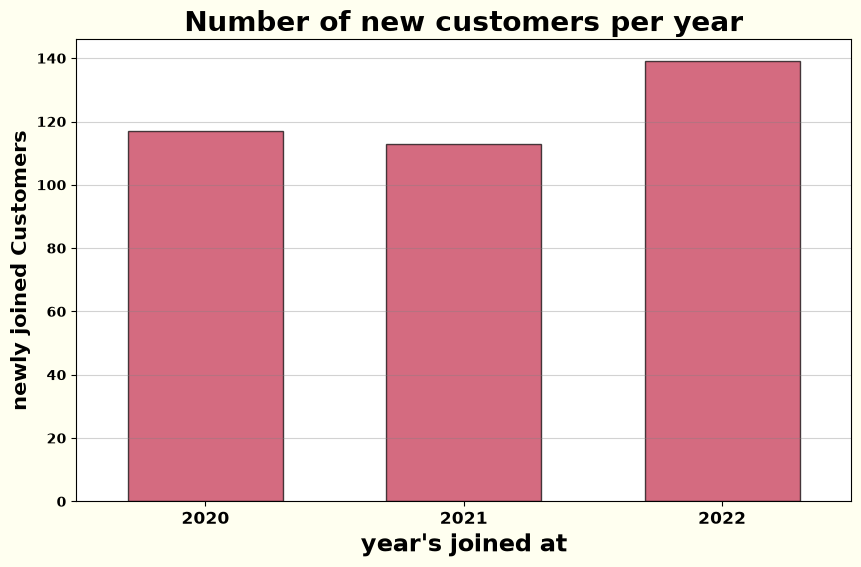

In [112]:
# Qestion 2
print(f'''[dark_orange]{'--'*25}[/dark_orange] [bold underline dark_orange] Qestion 2 [/bold underline dark_orange][dark_orange]{'--'*25}
{'--'*56}[/dark_orange]''')

################################################## part 2 - graphs analasys #################################################
print(f'[gold1]{'--'*22}[/gold1] [bold underline gold1] part 2 - graphs analasys [/bold underline gold1][gold1]{'--'*22}[/gold1]')

######################################## task 4 - Number of new customers per year ##########################################
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 4 - Number of new בustomers per year: [/underline spring_green1]')

###### determaning fig size and edge
plt.figure( figsize = (10,6), facecolor= 'ivory' )

###### creating a distribution graph for age + coloring it
    # converting date from str-dtype to datetime64[us]-dtype 
    # display(customers_no_X2['joining_date'].info)
customers_no_X2['joining_date'] = pd.to_datetime( customers['joining_date'] )

    # creating a temp col - joining_date - eith Year's of joining only and inserting it to sns.countplot
temp_customer_year_Joined = customers_no_X2.assign( year_joined = customers_no_X2['joining_date'].dt.year )

numb_bars_cyj = sns.countplot( data = temp_customer_year_Joined,
                               x = 'year_joined',
                               color = 'crimson',
                               edgecolor = 'black',
                               width= 0.6, alpha = 0.7)


for cont in numb_bars_cyj.containers: 
    numb_bars_nlt.bar_label( cont ,padding = 3, color = 'firebrick', fontweight = 'bold', fontsize= 12 )


###############################################  CHANGE
###### ploting the visualization of the data on the created graph i.e. - Title's, x/y label's,grid,  etc... 
plt.title( 'Number of new customers per year', fontsize=20, fontweight='bold')

# plt.xlim(2,85) 
plt.xlabel( "year's joined at", fontsize=17, fontweight='bold' )
plt.xticks( fontweight='bold', fontsize=12 )

# plt.ylim(0,55) 
plt.ylabel( 'newly joined Customers', fontsize=15, fontweight='bold' )
plt.yticks( fontweight='bold' )

plt.grid( which='major', axis= 'y', color='gray', alpha=0.35 )
plt.show()



############################### task 3 - Customer histography Distributionby of age ###############################

--------------------------------------------------  Qestion 2 --------------------------------------------------
----------------------------------------------------------------------------------------------------------------

--------------------------------------------  part 2 - graphs analasys --------------------------------------------

-- task 5 - Number of sales per month: 

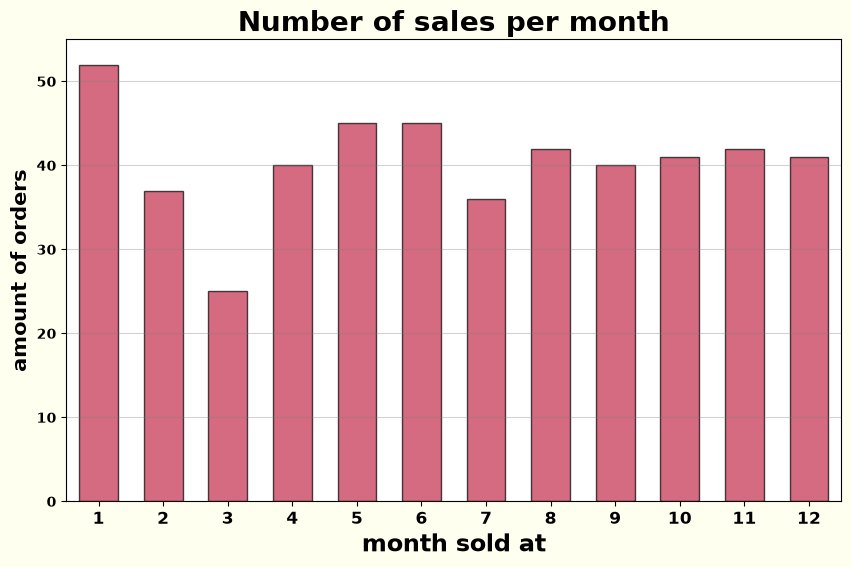

In [113]:
# Qestion 2
print(f'''[dark_orange]{'--'*25}[/dark_orange] [bold underline dark_orange] Qestion 2 [/bold underline dark_orange][dark_orange]{'--'*25}
{'--'*56}[/dark_orange]''')

################################################## part 2 - graphs analasys #################################################
print(f'[gold1]{'--'*22}[/gold1] [bold underline gold1] part 2 - graphs analasys [/bold underline gold1][gold1]{'--'*22}[/gold1]')

######################################## task 5 - Number of sales per month ##########################################
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 5 - Number of sales per month: [/underline spring_green1]')

###### Cleaning NaN values
orders_no_X2 = orders.dropna().copy()

###### determaning fig size and edge
plt.figure( figsize = (10,6), facecolor= 'ivory' )

orders_no_X2['order_date'] = pd.to_datetime( orders_no_X2['order_date'] )

    # creating a temp col - month_sold - with month's of purches for every order and inserting it to sns.countplot
temp_order_sold = orders_no_X2.assign( month_sold = orders_no_X2['order_date'].dt.month )

numb_bars_tos = sns.countplot( data = temp_order_sold,
                               x = 'month_sold',
                               color = 'crimson',
                               edgecolor = 'black',
                               width= 0.6, alpha = 0.7)


for cont in numb_bars_tos.containers: 
    numb_bars_nlt.bar_label( cont ,padding = 3, color = 'firebrick', fontweight = 'bold', fontsize= 12 )


###### ploting the visualization of the data on the created graph i.e. - Title's, x/y label's,grid,  etc... 
plt.title( 'Number of sales per month', fontsize=20, fontweight='bold')

# plt.xlim(2,85) 
plt.xlabel( "month sold at", fontsize=17, fontweight='bold' )
plt.xticks( fontweight='bold', fontsize=12 )

plt.ylim(0,55) 
plt.ylabel( 'amount of orders', fontsize=15, fontweight='bold' )
plt.yticks( fontweight='bold' )

plt.grid( which='major', axis= 'y', color='gray', alpha=0.35 )
plt.show()


--------------------------------------------------  Qestion 2 --------------------------------------------------
----------------------------------------------------------------------------------------------------------------

--------------------------------------------  part 2 - graphs analasys --------------------------------------------

-- task 6 - orders histography Distributionby by age: 

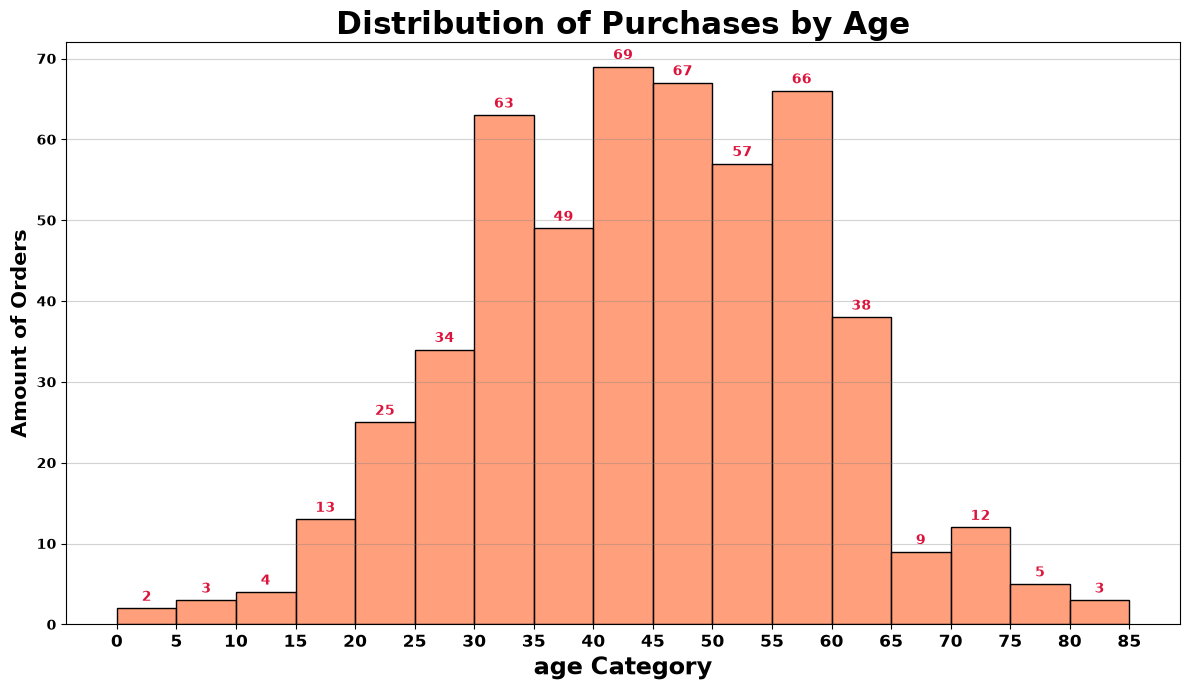

-- Anwer: 
You can see that between the ages of, 20 threw 65, are the majorety of consumers.
From the writen above we can deduce that, our main clintel are between the ages of arround their mud twent's until 
mid sixst'is/
(mostly- 30's to 60's).

In [114]:
# Qestion 2
print(f'''[dark_orange]{'--'*25}[/dark_orange] [bold underline dark_orange] Qestion 2 [/bold underline dark_orange][dark_orange]{'--'*25}
{'--'*56}[/dark_orange]''')

################################################## part 2 - graphs analasys #################################################
print(f'[gold1]{'--'*22}[/gold1] [bold underline gold1] part 2 - graphs analasys [/bold underline gold1][gold1]{'--'*22}[/gold1]')

# ############################### task 6 - orders histography Distributionby by age ###############################
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 6 - orders histography Distributionby by age: [/underline spring_green1]')

# ###### determaning fig size and edge
plt.figure(figsize=(12,7))

###### merging table - cusromes with order's

orders_customers_Ljoin = (
    orders.merge(customers, left_on='customer_id', right_on='id', how='left', suffixes=('_O', '_C')))

###### creating a distribution graph for age + coloring it + count on each bar
numb_bars_orcu = sns.histplot(data = orders_customers_Ljoin,
                             x = 'age',
                             bins=(np.arange(0,90,5)),
                             color = 'coral',
                            edgecolor = 'black')

for cont in numb_bars_orcu.containers: 
    numb_bars_orcu.bar_label(cont ,padding = 3, color = 'crimson', fontweight = 'bold')

###### ploting the visualization of the data on the created graph i.e. - Title's, x/y label's,grid,  etc... 
plt.title('Distribution of Purchases by Age', fontsize=22, fontweight='bold')

# plt.xlim(2,85) 
plt.xlabel('age Category', fontsize=17, fontweight='bold')
plt.xticks(np.arange(0,90,5), fontweight='bold', fontsize=12)

plt.ylim(0,72) 
plt.ylabel('Amount of Orders', fontsize=15, fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(which='major', axis= 'y', color='gray', alpha=0.35)
plt.tight_layout()
plt.show()

print(f'''\n[underline sea_green1]-- Anwer:[/underline sea_green1] [sea_green1]
You can see that between the ages of, 20 threw 65, are the majorety of consumers.
From the writen above we can deduce that, our main clintel are between the ages of arround their mud twent's until mid sixst'is/
(mostly- 30's to 60's).
[/sea_green1]''')




--------------------------------------------------  Qestion 2 --------------------------------------------------
----------------------------------------------------------------------------------------------------------------

--------------------------------------------  part 2 - graphs analasys --------------------------------------------

-- task 7 - orders cost by nationality: 

'orders cost by nationality'

,nationallity,total_sale
0,Argentina,304882.30
1,Brazil,247203.69
2,Chile,467299.35
3,China,162129.47
4,France,348308.96
5,Germany,300285.88
6,India,309703.67
7,Isreal,977233.82
8,Italy,316449.81
9,Japan,20113.94


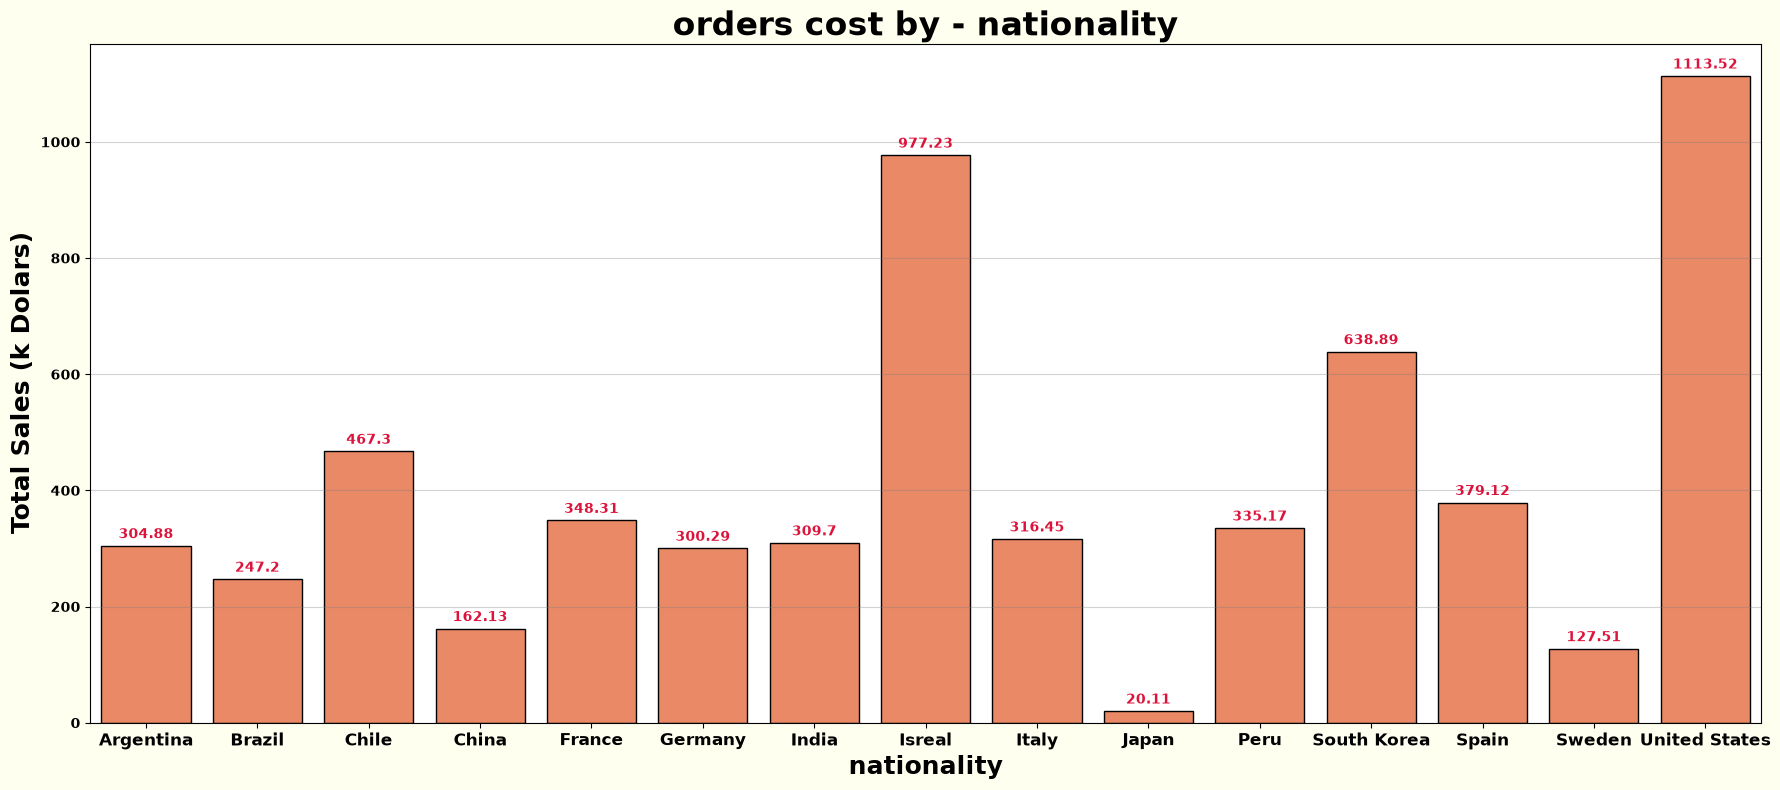

In [119]:
# Qestion 2
print(f'''[dark_orange]{'--'*25}[/dark_orange] [bold underline dark_orange] Qestion 2 [/bold underline dark_orange][dark_orange]{'--'*25}
{'--'*56}[/dark_orange]''')

################################################## part 2 - graphs analasys #################################################
print(f'[gold1]{'--'*22}[/gold1] [bold underline gold1] part 2 - graphs analasys [/bold underline gold1][gold1]{'--'*22}[/gold1]')

# ############################### task 7 - chalenge ###############################
print('\n[spring_green1]--[/spring_green1] [underline spring_green1]task 7 - orders cost by nationality: [/underline spring_green1]')

all_sales_data =(customers[['id','nationallity']]
    .merge(orders[['order_id', 'customer_id']], left_on='id', right_on='customer_id', how='left')
    .merge(order_item[['order_id', 'item_id', 'quantity']], on='order_id', how='left', suffixes=('_Ptm', '_oi'))
    .merge(Items[['id','item_price']], left_on='item_id', right_on='id', how='left', suffixes=('_CU', '_IT')))

all_sales_data['total_sale'] = all_sales_data['quantity'] * all_sales_data['item_price']

all_sales_per_nationality = all_sales_data.groupby('nationallity')['total_sale'].sum().reset_index()
display('orders cost by nationality',all_sales_per_nationality)


all_sales_per_nationality['total_cost_thousands'] =  round((all_sales_per_nationality['total_sale']/1000),2)

plt.figure(figsize=(18, 8), facecolor='ivory')
###### creating a distribution graph for age + coloring it + count on each bar
numb_bars_nat = sns.barplot(data = all_sales_per_nationality,
                            x = 'nationallity',
                            y= 'total_cost_thousands',
                            color = 'coral',
                            edgecolor = 'black')

for cont in numb_bars_nat.containers: 
    numb_bars_nat.bar_label(cont, padding=3, color='crimson', fontweight='bold')

###### ploting the visualization of the data on the created graph i.e. - Title's, x/y label's,grid,  etc... 
plt.title('orders cost by - nationality', fontsize=24, fontweight='bold')

# plt.xlim(2,85) 
plt.xlabel('nationality', fontsize=18, fontweight='bold')
plt.xticks(fontweight='bold', fontsize=12)

# plt.ylim(0,72) 
plt.ylabel('Total Sales (k Dolars)', fontsize=18, fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(which='major', axis= 'y', color='gray', alpha=0.35)
plt.tight_layout()
plt.show()